# CANADA: GIN

In [23]:
# General
from adjustText import adjust_text
import hdbscan
import itertools
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
from tqdm import tqdm

# GIN
from sklearn.metrics.pairwise import cosine_similarity

import torch
from torch.nn import Sequential, Identity, Module, Linear
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.utils import from_networkx

# uMAP
import umap.umap_ as umap

In [4]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
FEATURECOUNTS = INPUT + 'featureCounts/'

LINCS = INPUT + 'LDS-1481/'
LINCS_DEXP = LINCS + 'LDS-1481_1.0.gctx'
LINCS_GENE_INFO = LINCS + 'GSE92742_Broad_LINCS_gene_info.txt.gz'
LINCS_SIGNATURE_INFO = LINCS + 'GSE92742_Broad_LINCS_sig_info.txt.gz'
VST = INPUT + 'vstCounts/'

STRING = INPUT + 'string/'
STRING_EDGES = STRING + '9606.protein.physical.links.full.v12.0.txt.gz'
STRING_INFO = STRING + '9606.protein.info.v12.0.txt.gz'


OUTPUT = 'D:/DDesktop/_work/data/canada/output/'
TABULAR = OUTPUT + 'tabular/'
CONTEXT = OUTPUT + 'context_graphs/'

In [5]:
def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

# Analysis

## Graph List

In [118]:
# Set filter timepoint
filter_timepoint = '24H'

# Get graph list
list_graphs = [graph for graph in os.listdir(CONTEXT) if f'_{filter_timepoint}' in graph]

# Initialise graph list
pyg_graphs = []

# Iterate through graphs
for graph in tqdm(list_graphs, desc = f'Converting {filter_timepoint} context graphs to PyG objects', total = len(list_graphs)):

    # Get perturbagen id from filename
    perturbagen_name = graph.split('_')[1]
    # Get timepoint from filename
    timepoint = graph.split('_')[-1]
    timepoint = timepoint.split('.')[0]
    
    # Load data
    G = pickle_load(CONTEXT + graph)
    # Iterate through nodes
    for node in G.nodes:
        # Assign the `cd` attribute as `x`
        G.nodes[node]['x'] = [G.nodes[node]['cd']]
    
    # Convert to PyG object
    pyg = from_networkx(G)
    pyg.x = pyg.x.float()
    # Add perturbagen ID as name
    pyg.name = f'{perturbagen_name}'
    pyg.timepoint = f'{timepoint}'
    pyg_graphs.append(pyg)


# # Initialise graph list
# pyg_graphs = []

# # Iterate through files
# for graph in tqdm(os.listdir(CONTEXT), desc = 'Converting context graphs to PyG objects', total = len(os.listdir(CONTEXT))):
    
#     # Check for 6h graphs ONLY
#     if '_6H' in graph:

#         # Get perturbagen id from filename
#         perturbagen_name = graph.split('_')[1]
#         # Get timepoint from filename
#         timepoint = graph.split('_')[-1]
#         timepoint = timepoint.split('.')[0]
        
#         # Load data
#         G = pickle_load(CONTEXT + graph)
#         # Iterate through nodes
#         for node in G.nodes:
#             # Assign the `cd` attribute as `x`
#             G.nodes[node]['x'] = [G.nodes[node]['cd']]
        
#         # Convert to PyG object
#         pyg = from_networkx(G)
#         pyg.x = pyg.x.float()
#         # Add perturbagen ID as name
#         pyg.name = f'{perturbagen_name}'
#         pyg.timepoint = f'{timepoint}'
#         pyg_graphs.append(pyg)

Converting 24H context graphs to PyG objects: 100%|██████████| 497/497 [02:21<00:00,  3.51it/s]


## GIN

In [119]:
# Set desired embedding dimension
EMBED_DIM = 64

# Define GIN encoder using identity GINConvs and fixed projection to d dimensions
class GINEncoder(Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        
        # Project scalar node feature to d-dim before aggregation
        self.initial_proj = Linear(1, embed_dim)  # assuming input is 1-d per node

        # Identity "MLPs" in GINConv — only aggregate neighbors
        mlp1 = Sequential(Identity())
        mlp2 = Sequential(Identity())

        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)

        self.lin = Identity()  # optionally project again later

    def forward(self, x, edge_index):
        x = self.initial_proj(x)  # shape: [n, d]
        x = self.conv1(x, edge_index)
        x = F.relu(x)  # optional
        x = self.conv2(x, edge_index)
        return self.lin(x)  # shape: [n, d] — node-level embeddings

print('Identity-mapping GIN encoder complete')

# Instantiate model
encoder = GINEncoder()
encoder.eval()

print('Model instantiated')

# Storage for node-level and graph-level embeddings
node_embeddings = []   # list of (n_i × d) tensors
graph_embeddings = []  # list of (1 × d) tensors

with torch.no_grad():
    for graph in tqdm(pyg_graphs, desc='Generating embeddings', total=len(pyg_graphs)):
        x = encoder(graph.x, graph.edge_index)  # node-level: [n, d]
        node_embeddings.append(x)  # store full node-level embeddings

        # Create batch vector for global pooling
        batch = torch.zeros(x.size(0), dtype=torch.long)
        graph_emb = global_add_pool(x, batch)  # shape: [1, d]
        graph_embeddings.append(graph_emb)  # retain 1 × d without squeeze

# Convert graph-level embeddings to a matrix (m × d)
graph_embedding_matrix = torch.cat(graph_embeddings, dim=0).numpy()

Identity-mapping GIN encoder complete
Model instantiated


Generating embeddings:   0%|          | 0/497 [00:00<?, ?it/s]

Generating embeddings: 100%|██████████| 497/497 [00:00<00:00, 996.04it/s] 


## Cosine Similarity

The embedding matrix was 'centered' before normalisation by subtracting the mean vector value from said matrix. This allowed for better separation among embedding vectors.

For each of the 3 known crypto (`list_known_names`), cosine similarity to all other graph embedding vectors was calculated. This allowed for extraction of the $n$ most similar graphs to each anti-crypto.

In [120]:
# # Load data
# df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Set list_known_ids
list_known_ids = ['halo', 'paro', 'nita']
# Subtract mean vector and center matrix
centered = graph_embedding_matrix - graph_embedding_matrix.mean(axis=0, keepdims=True)
# Normalise centered values
centered_norm = centered / np.linalg.norm(centered, axis=1, keepdims=True)

# Initialise dataframe
df_centered = pd.DataFrame()

# Iterate through IDs
#for pert_name, timepoint in itertools.product(list_known_ids, ['6H', '24H']):
for pert_name, timepoint in itertools.product(list_known_ids, [filter_timepoint]):
    # Find index in pyg_graphs
    ref_idx = next(i for i, g in enumerate(pyg_graphs) if g.name == pert_name and g.timepoint == timepoint)
    
    # Calculate cosine similarity
    sims = cosine_similarity([centered_norm[ref_idx]], centered_norm)[0]
    # Sort values 
    sims_sort = np.sort(sims)[::-1]
    # Sort by closest similarity
    similarity = sims.argsort()[::-1]
    # Get graph pert_names
    similar_ids = [pyg_graphs[i].name for i in similarity]
    # Get graph timepoints
    timepoints = [pyg_graphs[i].timepoint for i in similarity]
    # # Convert to dataframe
    df_id = pd.DataFrame(similar_ids, columns = ['perturbagen_name'])
    # Add timepoint column
    df_id['timepoint'] = timepoints
    # # Merge
    # df_id = pd.merge(df_id, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
    # Add column
    df_id['value'] = sims_sort
    # Add ref column
    df_id['ref_name'] = pert_name
    df_id['ref_timepoint'] = timepoint
    #df_id['ref_name'] = df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == pert_name].values[0]
    # Concatenate
    df_centered = pd.concat([df_centered, df_id])

df_centered.head()

,perturbagen_name,timepoint,value,ref_name,ref_timepoint
0,halo,24H,1.000000,halo,24H
1,nita,24H,0.999995,halo,24H
2,paro,24H,0.999905,halo,24H
3,MW-SHH-151,24H,0.997610,halo,24H
4,elesclomol,24H,0.993902,halo,24H


## uMAP

In [121]:
# uMAP
reducer = umap.UMAP(n_components=2, random_state=42, spread = 1)
embedding_2d = reducer.fit_transform(centered_norm)
graph_ids = [g.name for g in pyg_graphs]
graph_timepoints = [g.timepoint for g in pyg_graphs]

# Convert to dataframe
df_plot = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_plot['perturbagen_name'] = graph_ids
df_plot['timepoint'] = graph_timepoints

# Show data
df_plot.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,x,y,perturbagen_name,timepoint
0,0.352075,10.364468,halo,24H
1,0.339022,10.347506,nita,24H
2,0.336594,10.352853,paro,24H
3,0.929317,-2.929125,15-delta-prostaglandin-j2,24H
4,0.970991,-3.804858,5'-guanidinonaltrindole,24H


C:\Users\roman\AppData\Local\Temp\ipykernel_31768\2418714479.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice.sort_values(by = 'value', ascending = False, inplace = True)


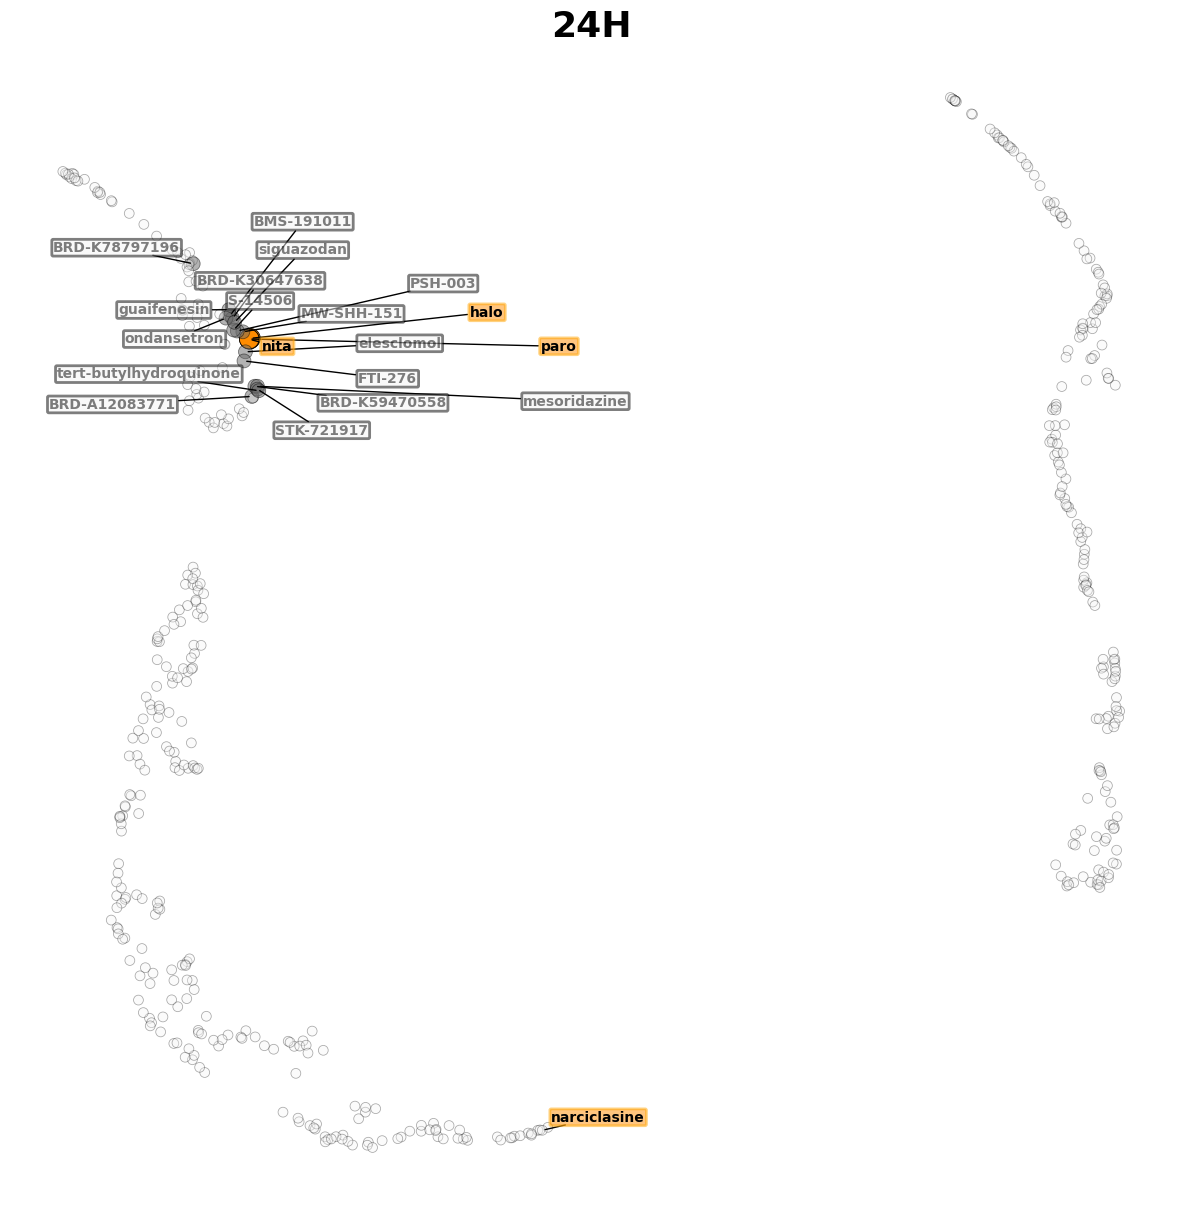

In [122]:
# Set filter timepoint
# filter_timepoint = '6H'

# Filter plot data
df_umap = df_plot[df_plot['timepoint'] == filter_timepoint].copy()
# # Filter pyg graphs
# pyg_filter = [g for g in pyg_graphs if g.timepoint == filter_timepoint]

# Set list of other drugs
list_other = ['narciclasine', 'asinomycin']

# Initialise list
list_highlight = []

# Iterate through df_centered
for ref_name in pd.unique(df_centered['ref_name']):
    # Slice dataframe
    df_slice = df_centered[(df_centered['ref_name'] == ref_name) &
                           (df_centered['ref_timepoint'] == filter_timepoint)]
    # Sort values
    df_slice.sort_values(by = 'value', ascending = False, inplace = True)
    # Get top 10 closest
    list_slice_highlight = df_slice['perturbagen_name'].iloc[1:16].tolist()
    # Add to list_highlight
    list_highlight.extend(list_slice_highlight)

# Set node colors
colors = ['darkorange' if g.name in list_known_ids else 'dimgrey' if g.name in list_highlight else 'whitesmoke' for g in pyg_filter]
#colors = ['darkorange' if g.name in list_known_ids else 'dimgrey' if g.name in list_highlight else 'whitesmoke' for g in pyg_filter]
# Set node sizes
#colors = [200 if g.name == mefloquine_id else 100 if g.name in list_known_ids else 'dimgrey' if g.name in list_highlight else 'whitesmoke' for g in pyg_graphs]
sizes = [200 if g.name in list_known_ids else 100 if g.name in list_highlight else 50 for g in pyg_filter]
# Set node alpha
alphas = [1 if g.name in list_known_ids else 0.5 if g.name in list_highlight else 0.33 for g in pyg_filter]

# Plot
plt.figure(figsize=(15, 15))
plt.axis('off')
sns.scatterplot(df_umap, x = 'x', y = 'y', c = colors, edgecolors = 'black', s = sizes, alpha = alphas);

# Label styling
# mefloquine_style = {'fontsize': 10, 
#                     'weight' : 'bold',
#                     'color': 'black',
#                     'bbox': {'facecolor': 'indianred',
#                              'alpha': 0.5,
#                              'edgecolor': 'red',
#                              'linewidth' : 2,
#                              'boxstyle': 'round,pad=0.1'}}

main_style = {'fontsize': 10, 
                  'weight' : 'bold',
                  'color': 'black',
                  'bbox': {'facecolor': 'darkorange',
                           'alpha': 0.5,
                           'edgecolor': 'orange',
                           'linewidth' : 2,
                           'boxstyle': 'round,pad=0.1'}}

highlight_style = {'fontsize': 10, 
                   'weight' : 'bold',
                   'color': 'black',
                   'alpha' : 0.5,
                   'bbox': {'facecolor': 'whitesmoke',
                            'alpha': 0.5,
                            'edgecolor': 'black',
                            'linewidth' : 2,
                            'boxstyle': 'round,pad=0.1'}}

# Intialise list
highlight_texts = []

# Iterate through perturbagen names
for name in pd.unique(df_umap['perturbagen_name']):
    # Slice dataframe
    df_slice = df_umap[df_umap['perturbagen_name'] == name]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]
    # Check if mefloquine
    # if name == mefloquine_id:
    #     # Add coordinates, label and stlying data
    #     highlight_texts.append(plt.text(x, y, label, **mefloquine_style));
    # Check if anti-malarial
    if name in list_known_ids:
        # Add coordinates, label and stlying data
        highlight_texts.append(plt.text(x, y, label, **main_style));
    # Check if in top 10 closest drugs
    elif name in list_highlight:
        # Add coordinates, label and stlying data
        highlight_texts.append(plt.text(x, y, label, **highlight_style));
    elif name in list_other:
        highlight_texts.append(plt.text(x, y, label, **main_style));

# Adjust labels
adjust_text(highlight_texts,
            arrowprops=dict(arrowstyle='-', color='black', lw = 1),
            expand = (1.75,1.75));

plt.title(filter_timepoint, fontsize = 26, fontweight = 'bold')
# Show plot
plt.show()

In [107]:
test = df_centered[(df_centered['ref_name'] == 'nita') &
                   (df_centered['ref_timepoint'] == filter_timepoint)]
# Sort values
test.sort_values(by = 'value', ascending = False, inplace = True)

#test.sort_values(by = ['ref_timepoint', 'value'], inplace = True)
test.head(15)

C:\Users\roman\AppData\Local\Temp\ipykernel_31768\3231349852.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.sort_values(by = 'value', ascending = False, inplace = True)


,perturbagen_name,timepoint,value,ref_name,ref_timepoint
0,nita,6H,1.000000,nita,6H
1,halo,6H,0.999995,nita,6H
2,paro,6H,0.999842,nita,6H
3,BRD-K73143528,6H,0.998537,nita,6H
4,dibenzoylmethane,6H,0.997727,nita,6H
5,STK-111867,6H,0.997717,nita,6H
6,BRD-K86693415,6H,0.997334,nita,6H
7,atorvastatin,6H,0.996845,nita,6H
8,MW-SHH-151,6H,0.996781,nita,6H
9,Merck60,6H,0.996512,nita,6H


In [132]:
# Initialise clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size = 15)
# Get cluster labels
labels = clusterer.fit_predict(embedding_2d)

# Initialise dataframe
df_cluster = df_plot.copy()
df_cluster['cluster'] = labels

# Report number of clusters identified
num_clusters = len(pd.unique(df_cluster['cluster']))
print(f'{num_clusters} clusters identified')

# Show data
df_cluster.head()

3 clusters identified


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x,y,perturbagen_name,timepoint,cluster
0,0.352075,10.364468,halo,24H,1
1,0.339022,10.347506,nita,24H,1
2,0.336594,10.352853,paro,24H,1
3,0.929317,-2.929125,15-delta-prostaglandin-j2,24H,2
4,0.970991,-3.804858,5'-guanidinonaltrindole,24H,2


In [133]:
# Initialise list
representatives = []

# Iterate through identified clusteres
for label, cluster in df_cluster.groupby('cluster'):
    # Check for labels > -1 (points designated as 'noise')
    if label > -1:
        # Get cluster centroid
        centroid = cluster[['x', 'y']].mean().values
        # Calculate distances of each drug in cluster to centroid
        distances = np.linalg.norm(cluster[['x', 'y']].values - centroid, axis=1)
        # Get closest drug
        closest_drug = cluster.index[np.argmin(distances)]
        # Append to list
        representatives.append(df_cluster.loc[closest_drug])
    
# Convert to dataframe
df_representatives = pd.DataFrame(representatives)
# Show data
df_representatives.head()

,x,y,perturbagen_name,timepoint,cluster
157,10.705444,7.467915,BRD-K60571253,24H,0
250,-0.515513,10.882595,diethylstilbestrol,24H,1
98,-0.799621,0.039377,BRD-K23342641,24H,2


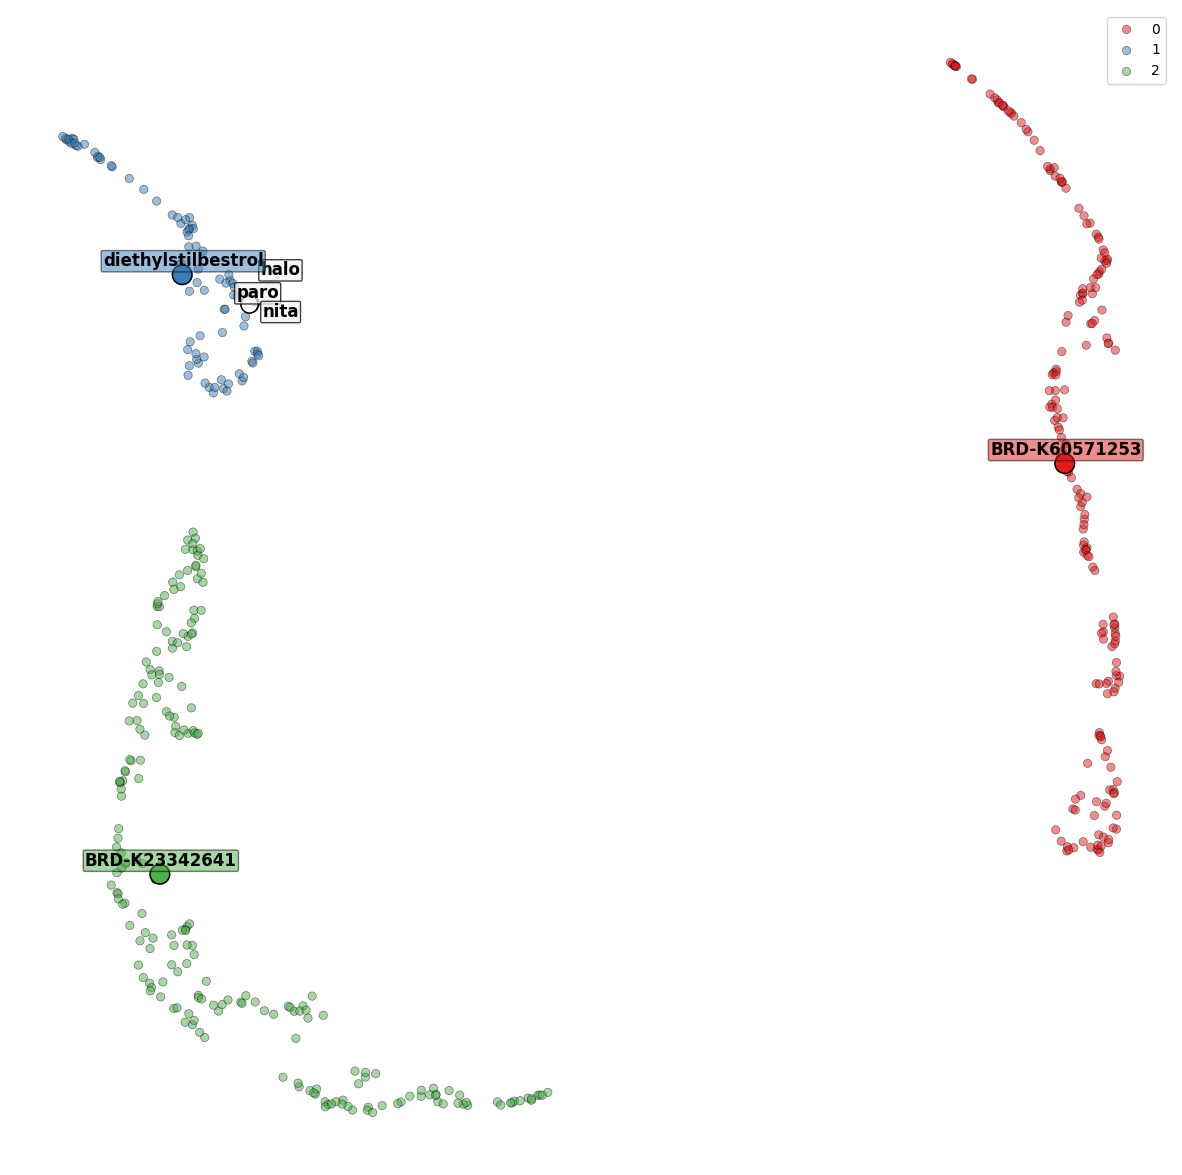

In [134]:
# Plot
plt.figure(figsize = (15,15))
plt.axis('off')

# Plot clusters
sns.scatterplot(df_cluster[df_cluster['cluster'] != -1], 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'Set1', 
                alpha = 0.5, edgecolors = 'black')
# Plot representative points
sns.scatterplot(df_representatives, 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'Set1', 
                edgecolors = 'black', s = 200, legend = False)
# Plot known anti-malarials
sns.scatterplot(df_cluster[df_cluster['perturbagen_name'].isin(list_known_ids)], 
                x = 'x', y = 'y', 
                c = 'white', s = 150, alpha = 1, edgecolors = 'black')

# Set label styling
malarial_style = {'fontsize': 12,
                  'alpha' : 1,
                  'weight' : 'bold',
                  'color': 'black',
                  'bbox': {'facecolor': 'whitesmoke',
                           'alpha': 0.75,
                           'edgecolor': 'black',
                           'boxstyle': 'round,pad=0.1'}}

# Initialise text label list
texts = []

# Iterate through anti-malarial IDs
for name in list_known_ids:
    # Slice dataframe
    df_slice = df_cluster[df_cluster['perturbagen_name'] == name]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]
    # Append with styling
    texts.append(plt.text(x, y, label, **malarial_style));

# Adjust labels
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25),
            expand = (1,1));

# Initialise representative text label list
rep_texts = []

# Get first n colours from Set1 palette
n = 10
palette_colors = list(sns.color_palette('Set1', n_colors=n))

# Iterate through representative drug IDs and palette colours
for name, colour in zip(pd.unique(df_representatives['perturbagen_name']), palette_colors):
    # Slice dataframe
    df_slice = df_representatives[df_representatives['perturbagen_name'] == name]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]

    # Set label styling
    rep_style = {'fontsize': 12,
                 'alpha' : 1,
                 'weight' : 'bold',
                 'color': 'black',
                 'ha': 'center',             
                 'va': 'bottom',             
                 'bbox': {'facecolor': colour,
                          'alpha': 0.5,
                          'edgecolor': 'black',
                          'boxstyle': 'round,pad=0.1'}}

    # Append with styling
    rep_texts.append(plt.text(x, y, label, **rep_style))

# Adjust text labels
adjust_text(rep_texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25));

# Show plot
plt.show()